# Treinamento com MNIST (Banco de Imagens)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Puxando o arquivo da pasta src que criamos
import sys
sys.path.append('../src')
from model import CNN

# Verificando se tem GPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando na: {device}")

Rodando na: cpu


In [2]:
# Resize entra para garantir que qualquer dataset fique 28x28
transform = transforms.Compose([
    transforms.Resize((28, 28)), 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalização básica
])

# Baixando o MNIST (vai salvar automaticamente em data/)
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [3]:
# Aqui passamos num_canais=1 porque o MNIST é preto e branco (tons de cinza)
modelo = CNN(num_canais=1, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
# Adam escolhido pois costuma convergir mais rápido que o SGD padrão e na atividade passada foi melhor
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

In [4]:
epocas = 5 # 5 épocas 
historico_loss = []

modelo.train() # Avisa o pytorch que estamos treinando (importante por causa do dropout)

for epoch in range(epocas):
    loss_acumulada = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes da iteração anterior
        optimizer.zero_grad()

        # Forward (passa pra frente)
        outputs = modelo(inputs)
        loss = criterion(outputs, labels)
        
        # Backward (passa pra trás atualizando os pesos)
        loss.backward()
        optimizer.step()

        loss_acumulada += loss.item()
    
    loss_media = loss_acumulada / len(trainloader)
    historico_loss.append(loss_media)
    print(f"Época {epoch+1}/{epocas} - Loss: {loss_media:.4f}")

Época 1/5 - Loss: 0.2170
Época 2/5 - Loss: 0.0919
Época 3/5 - Loss: 0.0753
Época 4/5 - Loss: 0.0654
Época 5/5 - Loss: 0.0556


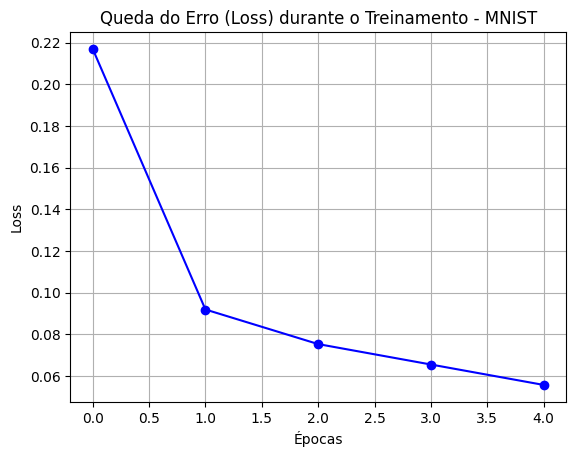

In [5]:
plt.plot(historico_loss, marker='o', color='b')
plt.title('Queda do Erro (Loss) durante o Treinamento - MNIST')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Treinamento com CIFAR

In [6]:
# cifar tem 3 canais, entao a normalizacao precisa de 3 valores (um pro R, G e B)
transform_cifar = transforms.Compose([
    transforms.Resize((28, 28)), # forçando o 28x28 pra nossa rede nao quebrar
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# baixando o dataset de treino e teste
trainset_cifar = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_cifar)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=64, shuffle=True)

testset_cifar = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_cifar)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=64, shuffle=False)

In [7]:
# a unica diferenca aqui eh o num_canais=3
modelo_cifar = CNN(num_canais=3, num_classes=10).to(device)

optimizer_cifar = optim.Adam(modelo_cifar.parameters(), lr=0.001)

epocas_cifar = 5 
historico_loss_cifar = []

modelo_cifar.train() 

print("Começando o treino no CIFAR10...")
for epoch in range(epocas_cifar):
    loss_acumulada = 0.0
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_cifar.zero_grad()

        outputs = modelo_cifar(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer_cifar.step()

        loss_acumulada += loss.item()
    
    loss_media = loss_acumulada / len(trainloader_cifar)
    historico_loss_cifar.append(loss_media)
    print(f"Época {epoch+1}/{epocas_cifar} - Loss: {loss_media:.4f}")

Começando o treino no CIFAR10...
Época 1/5 - Loss: 1.5416
Época 2/5 - Loss: 1.2924
Época 3/5 - Loss: 1.1939
Época 4/5 - Loss: 1.1261
Época 5/5 - Loss: 1.0832


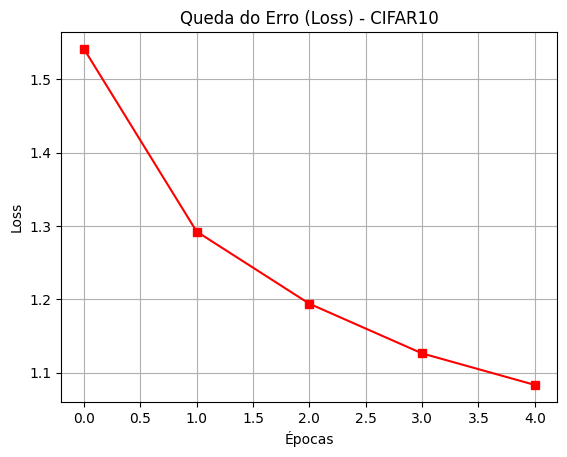

In [8]:
# mais um grafico pro documento
plt.plot(historico_loss_cifar, marker='s', color='r')
plt.title('Queda do Erro (Loss) - CIFAR10')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [9]:
# funcao simples pra testar o modelo e devolver a % de acerto
def calcula_acuracia(modelo, testloader):
    modelo.eval() # avisa a rede pra desligar o dropout
    acertos = 0
    total = 0
    
    # corta o calculo de gradiente pra poupar memoria
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = modelo(inputs)
            # pega a classe com a maior pontuacao (o q a rede acha q eh a imagem)
            _, previsao = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            acertos += (previsao == labels).sum().item()
            
    acuracia = 100 * acertos / total
    return acuracia

In [10]:
print("Calculando acertos, aguarde...")

# testando nossa cnn no mnist
acc_mnist = calcula_acuracia(modelo, testloader)
print(f"Acurácia da minha CNN no MNIST: {acc_mnist:.2f}%")

# testando a mesma arquitetura no cifar10
acc_cifar = calcula_acuracia(modelo_cifar, testloader_cifar)
print(f"Acurácia da minha CNN no CIFAR10: {acc_cifar:.2f}%")

Calculando acertos, aguarde...
Acurácia da minha CNN no MNIST: 98.97%
Acurácia da minha CNN no CIFAR10: 65.53%


# Estudo de Ablação

Rodando na: cpu
Iniciando Estudo de Ablação no CIFAR10 (Sem Dropout e sem BatchNorm)...
Época 1/5 [Ablada] - Loss: 1.5107
Época 2/5 [Ablada] - Loss: 1.2076
Época 3/5 [Ablada] - Loss: 1.0582
Época 4/5 [Ablada] - Loss: 0.9536
Época 5/5 [Ablada] - Loss: 0.8708
Acurácia da CNN Ablada (sem regularização) no CIFAR10: 65.92%
Acurácia da CNN Original no CIFAR10: 65.53%


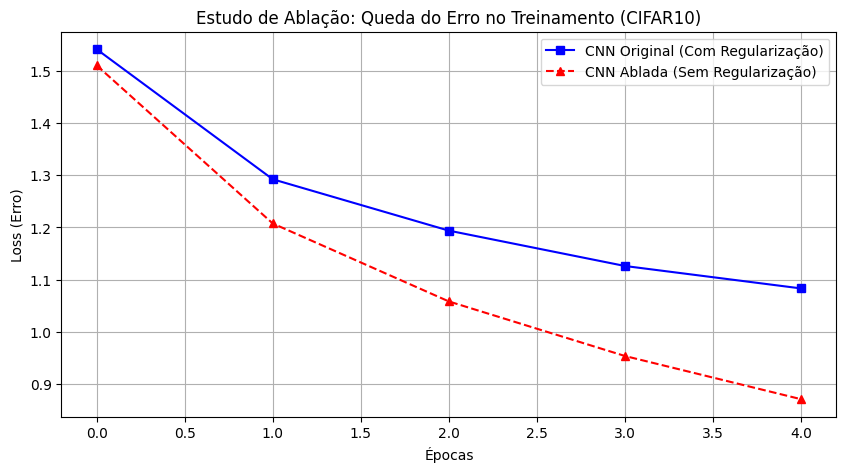

In [12]:
import sys
sys.path.append('../src') 

from model import CNN_Ablada #
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# é nescessário redefinir o device para caso seja rodado isoladamente 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando na: {device}")

print("Iniciando Estudo de Ablação no CIFAR10 (Sem Dropout e sem BatchNorm)...")

# Instancia o modelo ablado
modelo_ablado = CNN_Ablada(num_canais=3, num_classes=10).to(device)
optimizer_ablado = optim.Adam(modelo_ablado.parameters(), lr=0.001)

historico_loss_ablada = []
modelo_ablado.train() 

for epoch in range(epocas_cifar):
    loss_acumulada = 0.0
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_ablado.zero_grad()
        outputs = modelo_ablado(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer_ablado.step()
        loss_acumulada += loss.item()
        
    loss_media = loss_acumulada / len(trainloader_cifar)
    historico_loss_ablada.append(loss_media)
    print(f"Época {epoch+1}/{epocas_cifar} [Ablada] - Loss: {loss_media:.4f}")

# Testando a acurácia do modelo ablado
acc_ablada = calcula_acuracia(modelo_ablado, testloader_cifar)
print(f"Acurácia da CNN Ablada (sem regularização) no CIFAR10: {acc_ablada:.2f}%")
print(f"Acurácia da CNN Original no CIFAR10: {acc_cifar:.2f}%")

# Gráfico de comparação (DESAFIO DA ABLAÇÃO)
plt.figure(figsize=(10,5))
plt.plot(historico_loss_cifar, marker='s', color='blue', label='CNN Original (Com Regularização)')
plt.plot(historico_loss_ablada, marker='^', color='red', linestyle='--', label='CNN Ablada (Sem Regularização)')
plt.title('Estudo de Ablação: Queda do Erro no Treinamento (CIFAR10)')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro)')
plt.legend()
plt.grid(True)
plt.show()

### Validação em mais epócas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Garantindo o device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando Validação Longa na: {device}")

# 2. Reiniciando os dois modelos do absoluto zero
modelo_original = CNN(num_canais=3, num_classes=10).to(device)
modelo_ablado = CNN_Ablada(num_canais=3, num_classes=10).to(device)

opt_orig = optim.Adam(modelo_original.parameters(), lr=0.001)
opt_abl = optim.Adam(modelo_ablado.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epocas_teste = 15 # Tempo suficiente para forçar o overfitting na Ablada

hist_acc_orig, hist_acc_abl = [], []
hist_loss_orig, hist_loss_abl = [], []

print(f"Iniciando corrida de {epocas_teste} épocas. Pegue um café, isso vai demorar um pouco...\n")

# Treinamento
for epoch in range(epocas_teste):

    modelo_original.train()
    modelo_ablado.train()
    
    loss_acum_orig, loss_acum_abl = 0.0, 0.0
    
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Treinando a CNN Original
        opt_orig.zero_grad()
        out_orig = modelo_original(inputs)
        loss_orig = criterion(out_orig, labels)
        loss_orig.backward()
        opt_orig.step()
        loss_acum_orig += loss_orig.item()
        
        # Treinando a CNN Ablada
        opt_abl.zero_grad()
        out_abl = modelo_ablado(inputs)
        loss_abl = criterion(out_abl, labels)
        loss_abl.backward()
        opt_abl.step()
        loss_acum_abl += loss_abl.item()
        
    hist_loss_orig.append(loss_acum_orig / len(trainloader_cifar))
    hist_loss_abl.append(loss_acum_abl / len(trainloader_cifar))

    # Validation
    modelo_original.eval()
    modelo_ablado.eval()
    
    acertos_orig, total_orig = 0, 0
    acertos_abl, total_abl = 0, 0
    
    with torch.no_grad():
        for inputs, labels in testloader_cifar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Avaliando Original
            out_orig = modelo_original(inputs)
            _, prev_orig = torch.max(out_orig, 1)
            acertos_orig += (prev_orig == labels).sum().item()
            total_orig += labels.size(0)
            
            # Avaliando Ablada
            out_abl = modelo_ablado(inputs)
            _, prev_abl = torch.max(out_abl, 1)
            acertos_abl += (prev_abl == labels).sum().item()
            total_abl += labels.size(0)
            
    acc_orig = 100 * acertos_orig / total_orig
    acc_abl = 100 * acertos_abl / total_abl
    
    hist_acc_orig.append(acc_orig)
    hist_acc_abl.append(acc_abl)
    
    print(f"Época {epoch+1:02d}/{epocas_teste} | "
          f"Loss (Orig/Abl): {hist_loss_orig[-1]:.3f} / {hist_loss_abl[-1]:.3f} | "
          f"Acc Teste (Orig/Abl): {acc_orig:.1f}% / {acc_abl:.1f}%")

# Plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da Esquerda: Loss de Treino (Onde a Ablada parece ser melhor)
ax1.plot(hist_loss_orig, marker='s', color='blue', label='CNN Original (Com Dropout)')
ax1.plot(hist_loss_abl, marker='^', color='red', linestyle='--', label='CNN Ablada (Sem Dropout)')
ax1.set_title('Loss de Treinamento')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Erro (Loss)')
ax1.legend()
ax1.grid(True)

# Gráfico da Direita: Acurácia Real (A verdade do Overfitting)
ax2.plot(hist_acc_orig, marker='s', color='blue', label='CNN Original (Com Dropout)')
ax2.plot(hist_acc_abl, marker='^', color='red', linestyle='--', label='CNN Ablada (Sem Dropout)')
ax2.set_title('Acurácia no Conjunto de TESTE')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Acurácia (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Estudo de Ablação Estendido: O Impacto da Regularização a Longo Prazo', fontsize=16)
plt.tight_layout()
plt.show()

Rodando Validação Longa na: cpu
Iniciando corrida de 15 épocas. Pegue um café, isso vai demorar um pouco...

